# Import

In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import warnings
import matplotlib.pyplot as plt
import sys 
import os 
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import seaborn as sns
from tqdm import tqdm
from scipy.stats import linregress
import matplotlib.patches as mpatches
from scipy.stats import pearsonr, spearmanr
from pandas.api.types import CategoricalDtype

plt.rcParams["figure.figsize"]=4,4

warnings.filterwarnings("ignore")


# - dirs 
from ciim.src.common import cell_types, datasets_e, datasets_a, datasets_all, palette_datasets_pretty, palette_datasets, surrogate_names, colors_blind, palette_trend, palette_trend_2, palette_regulation, palette_cell_types, palette_genders, mapping_minor_2_major

from ciim.src.tf_activity.helper import retrieve_adata_bulk, retrieve_feature_data, retrieve_net, calculate_tf_activity, compute_trend, retrieve_sig_stats, retrieve_valid_stats, retrieve_stats_features

from ciim.src.tf_activity.plots import plot_net_nx, plot_sig_tfs_stats

from ciim.src.utils.plots import dotplot
# from ciim.src.tf_activity.helper import retreive_stats

task_grn_inference_dir = '../../task_grn_inference'


def filter_for_consistent_trends(df):
    consistent_groups = (
        df.groupby(['cell_type', 'tf'])['slope']
        .apply(lambda x: np.sign(x).nunique() == 1)
    )
    valid_tuples = consistent_groups[consistent_groups].index
    filtered_df = df.set_index(['cell_type', 'tf']).loc[valid_tuples].reset_index()
    return filtered_df

# Some funcs or unknown sections

In [3]:
def compile_data(cell_type, target_tfs, target_filter_criteria='in_degree_c'):
    stats_tf = stats_valid[(stats_valid['cell_type']==cell_type) & (stats_valid['tf'].isin(target_tfs))]
    stats_targets = stats_targets_all[stats_targets_all['cell_type']==cell_type]
    net = consensus_nets_dict[cell_type]
    print('Put the data together ...')
    data_all = obj.wrapper_retreive_stats(stats_tf, stats_targets, net, filter_criteria=target_filter_criteria,
                n_top_targets=20)
    return data_all
if False:
    from ciim.src.tf_activity.plots import DotPlotTFtarget

    obj = DotPlotTFtarget(tf_all, skeleton)
    obj.plot_legend()
    data = compile_data(cell_type, sig_tfs_ts_sorted, target_filter_criteria='meta_p_adj_target')
    obj.plot_dotplot(data, 
                    figsize=(6, 5), 
                    height_ratios=(4, .3), 
                    width_ratios=[0.2, 4], 
                    ax_main_margin=(0.04, .1),
                    title=f"Common TFs to T cells: {cell_type}")
    # - store the net
    net = data[['source', 'target', 'weight', 'trend','trend_target']].drop_duplicates()
    net_dicts[cell_type] = net



# Bulk main

## Heatmap of sig TFs across cell types and cohorts

In [35]:
# - read all stats (with and without significance) and add is_significant to mark the significant ones
type = 'bulk'

stats_all = pd.read_csv(f'../output/tf_activity/stats_all_{type}.csv')
stats_all = stats_all[stats_all['race']=='both']

# - add sig signs
stats_sig = retrieve_sig_stats(type, race='both')
tuple_index = stats_sig.set_index(['cell_type', 'tf', 'dataset']).index
stats_all = stats_all.set_index(['cell_type', 'tf', 'dataset'])
stats_all['is_significant'] = False
stats_all.loc[tuple_index, 'is_significant'] = True
stats_all = stats_all.reset_index()[['tf', 'cell_type', 'dataset', 'slope', 'is_significant']].drop_duplicates()

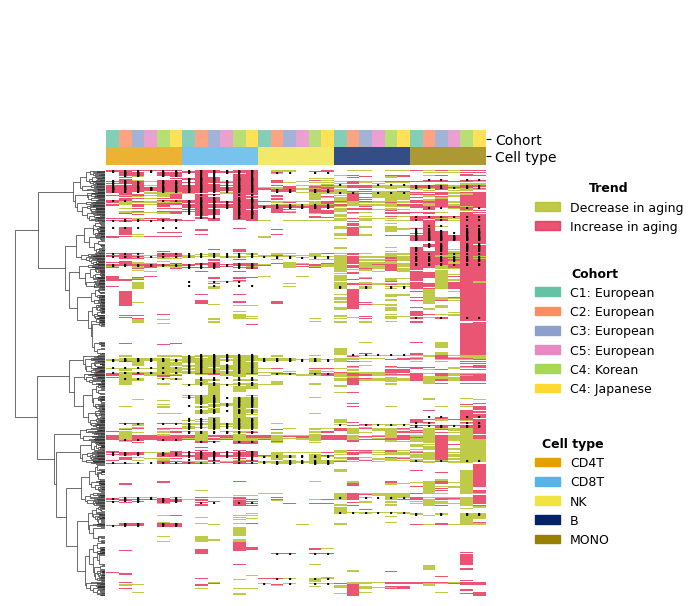

In [37]:
from ciim.src.tf_activity.plots import plot_overall_heatmap


stats_all['cell_type'] = pd.Categorical(stats_all['cell_type'], categories=cell_types, ordered=True)
stats_all['dataset'] = pd.Categorical(stats_all['dataset'], categories=datasets_all, ordered=True)

plot_overall_heatmap(stats_all, 
                    sig_dots_y_offset=4, 
                    first_col='cell_type',  first_col_palette=palette_cell_types,
                    second_col='dataset', second_col_palette=palette_datasets,
                    bbox_to_anchor_col2=(1.1, .8),
                    figsize=(6, 8),
                    map_names={**{'cell_type':'Cell type', 'dataset': 'Cohort'}, **surrogate_names})
# plt.savefig(f'../output/tf_activity/overall_heatmap_{type}.png', bbox_inches='tight', dpi=300)

## Sig TFs counts

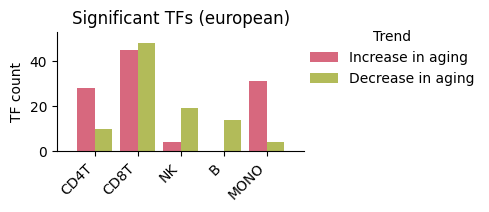

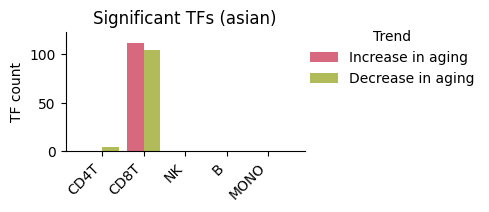

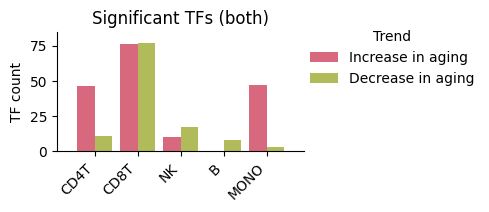

In [38]:
for race in ['european', 'asian', 'both']:
    stats = retrieve_sig_stats(type='bulk', race=race, filter_inconsistent=True).drop_duplicates(subset=['cell_type', 'tf'])
    # plt.savefig(f'../output/tf_activity/trends.png', dpi=300)
    stats['cell_type'] = pd.Categorical(stats['cell_type'], categories=cell_types, ordered=True)
    plot_sig_tfs_stats(stats, figsize=(5, 2))
    plt.title(f'Significant TFs ({race})')

## Intersection of races

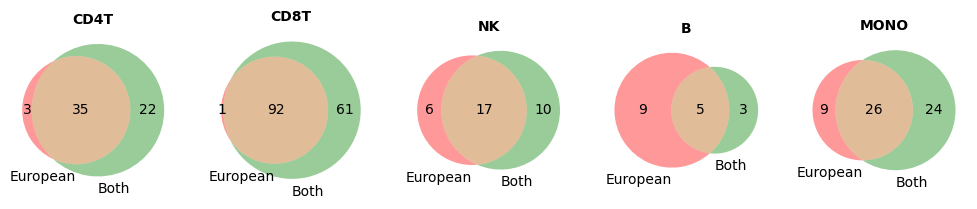

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

type = 'bulk'
# Collect stats as sets of significant TFs for each analysis and cell type
stats_e = retrieve_sig_stats(type, race='european')
stats_a = retrieve_sig_stats(type, race='both')


fig, axes = plt.subplots(1, len(cell_types), figsize=(2 * len(cell_types), 2))

if len(cell_types) == 1:
    axes = [axes]

for ax, cell_type in zip(axes, cell_types):

    set_e = set(stats_e[stats_e['cell_type'] == cell_type]['tf'].unique())
    set_a = set(stats_a[stats_a['cell_type'] == cell_type]['tf'].unique())

    v = venn2([set_e, set_a], set_labels=('European', 'Both'), ax=ax)
    for text in v.set_labels:
        if text: text.set_fontsize(10)
    for text in v.subset_labels:
        if text: text.set_fontsize(10)
    ax.set_title(cell_type, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## Cell type specific plots: explicit dataset stats

In [40]:
from ciim.src.tf_activity.helper import retrieve_sig_stats, retrieve_valid_stats
type = 'bulk'

stats_all = pd.read_csv(f'../output/tf_activity/stats_all_{type}.csv')

def subset_func(df1, df2, mode_f=np.intersect1d):
    df_store = []
    for cell_type in df1['cell_type'].unique():
        # - subset
        df1_sub = df1[df1['cell_type'] == cell_type]
        df2_sub = df2[df2['cell_type'] == cell_type]
        # - subset
        tfs = mode_f(df1_sub['tf'].unique(), df2_sub['tf'].unique())
        # - subset
        df1_sub = df1_sub[df1_sub['tf'].isin(tfs)]
        df_store.append(df1_sub)
    df1 = pd.concat(df_store)
    return df1

if False:
    stats_sig_1 = retrieve_sig_stats(type, race='european') 
    stats_sig_2 = retrieve_sig_stats(type, race='asian')
    stats_sig = subset_func(stats_sig_1, stats_sig_2, mode_f=np.intersect1d)
else:
    stats_sig = retrieve_sig_stats(type, race='european', filter_inconsistent=False)

tupled_index = stats_sig.set_index(['cell_type', 'tf']).index
stats_all = stats_all.set_index(['cell_type', 'tf']).loc[tupled_index].reset_index().drop_duplicates(subset=['cell_type', 'tf', 'dataset'])

# - only keep the consistent ones
# sign_df = stats_all.groupby(['cell_type', 'tf'])['slope'].apply(lambda x: np.sign(x).nunique() == 1)
# tuple_index = sign_df[sign_df].index
# stats_all = stats_all.set_index(['cell_type', 'tf']).loc[tuple_index].reset_index()

True


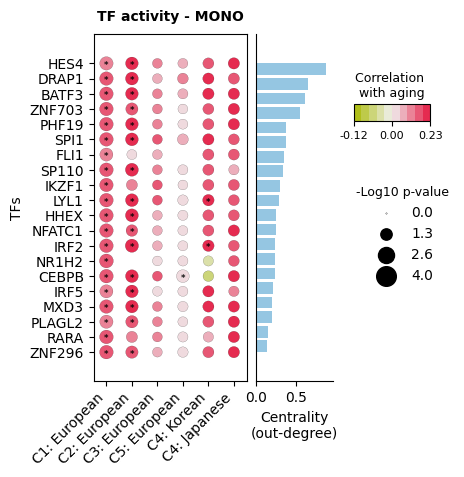

In [41]:
from ciim.src.tf_activity.plots import plot_features_vs_datasets

cell_type = 'MONO'
type = 'bulk'
plot_features_vs_datasets(cell_type=cell_type, type=type, datasets=datasets_all, features=None, width=4,
                            feature_type='tf_activity', sizes=(50, 100), min_degree=4, filter_meta_significant=True)
# plt.savefig(f'../output/test.png', bbox_inches='tight', dpi=300)

## Modularize the interactions

In [10]:
from ciim.src.tf_activity.plots import ModularizedNetPlot
cell_type = 'CD8T'
min_degree = 3
race='european'
type='bulk'

net = ModularizedNetPlot.prepare_net_only_tfs(cell_type, race, type, min_degree)
collapsed_net = ModularizedNetPlot.collapse_nets(net)
collapsed_net = ModularizedNetPlot.add_trend_to_collapsed_net_only_tfs(collapsed_net, type, race, cell_type)
collapsed_net.head()

,source,target,weight,trend_source,trend_target
0,ASCL2,BATF,1.0,Increase in aging,Increase in aging
1,ASCL2,FOXP1/MYC,-1.0,Increase in aging,Decrease in aging
2,BCL11B/PLAG1/TFAP4,FOXP1/MYC,1.0,Decrease in aging,Decrease in aging
3,BCL11B/PLAG1/TFAP4,LEF1/SATB1,1.0,Decrease in aging,Decrease in aging
4,BHLHE40/IRF1,AKNA/PRDM1,1.0,Increase in aging,Increase in aging


In [11]:
collapsed_net.to_csv(f'../output/nets/collapsed_net_{cell_type}.csv', index=False)

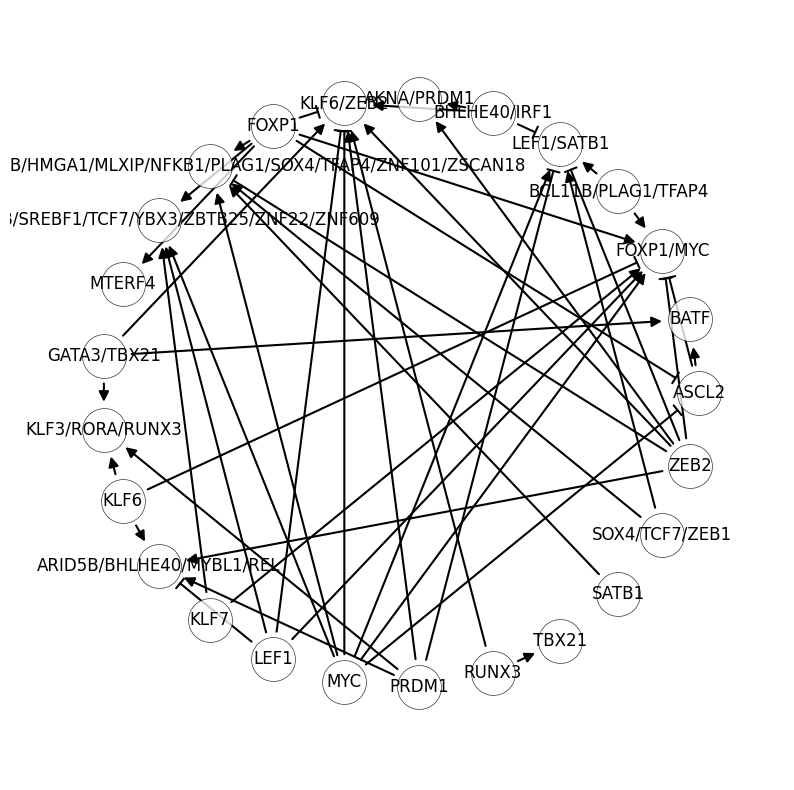

In [12]:
figsize = (10, 10)
draw_evidence = False
offset_evidence = 0.1
arc_offset = 0.05
plot_net_nx(collapsed_net, figsize=figsize, draw_evidence=draw_evidence, palette_evidence=palette_datasets, offset_evidence=offset_evidence, arc_offset=arc_offset)

In [13]:
!ls /home/jnourisa/projs/ongoing/ciim/output/sig_nets/

sig_nets_bulk_asian.csv  sig_nets_bulk_both.csv  sig_nets_bulk_european.csv


In [14]:
from ciim.src.tf_activity.plots import ModularizedNetPlot
cell_type = 'CD8T'
min_degree = 3
race='both'
type='bulk'

net = retrieve_sig_net(type, race, cell_type=cell_type)
collapsed_net = ModularizedNetPlot.collapse_nets(net)
collapsed_net = ModularizedNetPlot.add_trend_to_collapsed_net(collapsed_net, net)
collapsed_net.head()

NameError: name 'retrieve_sig_net' is not defined

In [205]:
collapsed_net.to_csv(f'../output/nets/collapsed_sig_net_{cell_type}.csv', index=False)

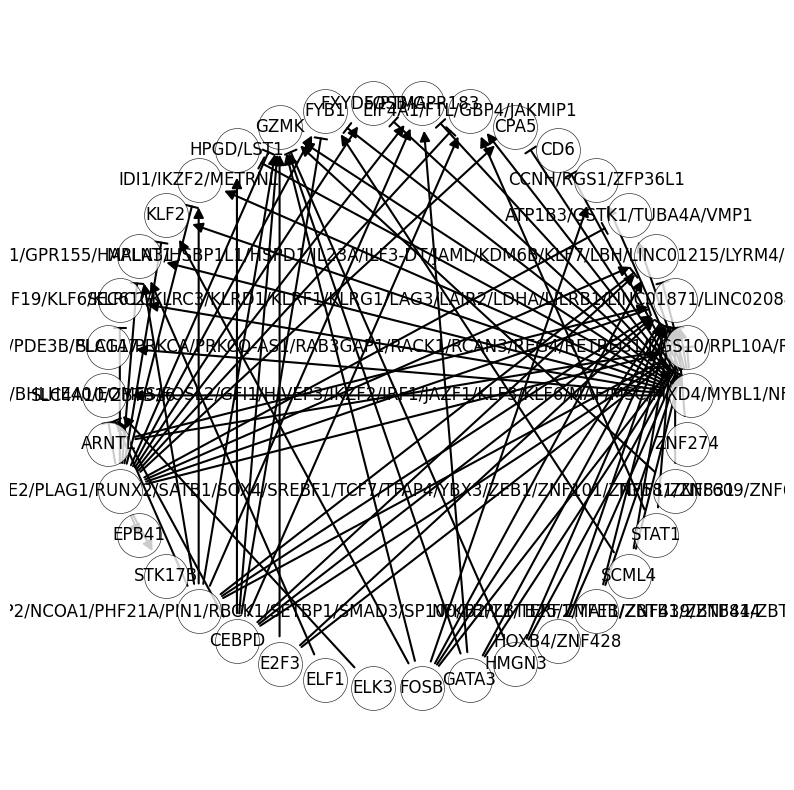

In [204]:
figsize = (10, 10)
draw_evidence = False
offset_evidence = 0.1
arc_offset = 0.05
plot_net_nx(collapsed_net, figsize=figsize, draw_evidence=draw_evidence, palette_evidence=palette_datasets, offset_evidence=offset_evidence, arc_offset=arc_offset)

## Identify sig networks

In [5]:
from ciim.src.tf_activity.helper import determine_sig_network

type = 'bulk'

if True:
    for race in ['european','both']:
        determine_sig_network(type, race, min_degree=3)

In [175]:
from ciim.src.tf_activity.helper import retrieve_sig_net
cell_type = 'CD8T'
type = 'bulk'
race = 'both'
tfs = ['JUND', 'TCF7', 'MYC', 'BACH2']

sig_net = retrieve_sig_net(type, race, cell_type)
sig_net['sign'] = np.sign(sig_net['weight'])
sig_net.shape

(18224, 9)

### Network topology

In [106]:
tf_all = np.loadtxt(f'{task_grn_inference_dir}/resources/grn_benchmark/prior/tf_all.csv', dtype=str)

nets = pd.read_csv(f'../output/sig_nets/sig_nets_{type}_{race}.csv')

In [68]:
# nets['cell_type'].unique()

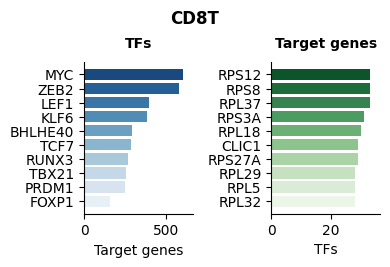

In [107]:
from ciim.src.tf_activity.plots import plot_net_degrees

for cell_type in ['CD8T']:
    net = nets[nets['cell_type'] == cell_type]
    plot_net_degrees(net)
    plt.suptitle(f'{cell_type}', fontsize=12, y=1.05, fontweight='bold')
    

## Interaction of aging TFs between cell types

### T cells

In [37]:
from task_grn_inference.src.exp_analysis.helper import plot_interactions, create_interaction_df

type = 'bulk'
race='both'
stats_sig = retrieve_sig_stats(type=type, race=race).drop_duplicates(subset=['cell_type', 'tf'])
df_dict = stats_sig.groupby(['cell_type'])['tf'].apply(list).to_dict()
interaction_main_df = create_interaction_df(df_dict)

['CD8T', 'CD4T', 'MONO', 'NK', 'B']


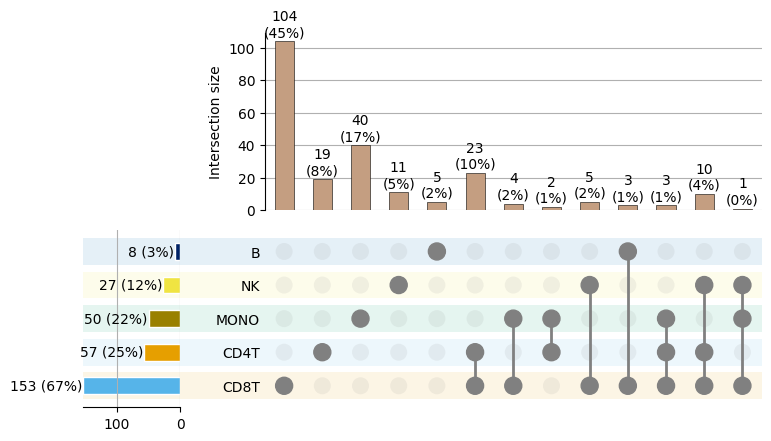

In [38]:
aa = plot_interactions(interaction_main_df, min_subset_size=1, min_degree=1, color_map=palette_cell_types)
# plt.savefig(f'../output/tf_activity/interactions.png', dpi=300)
# plt.title(surrogate_names[race], pad=40, fontsize=10, fontweight='bold')

8


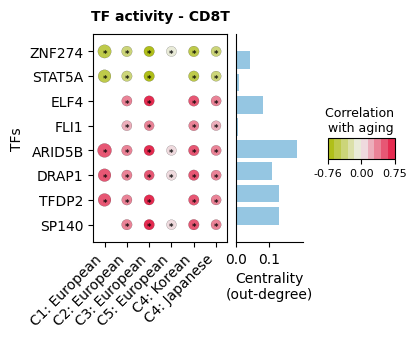

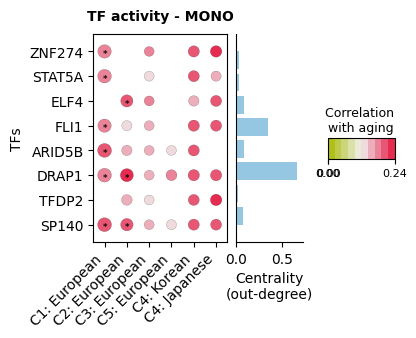

In [ ]:
from ciim.src.tf_activity.plots import plot_features_vs_datasets

ttypes = ['CD8T', 'CD4T', 'NK']
mask = interaction_main_df[ttypes].sum(axis=1)==len(ttypes)
features = mask[mask].index.unique()
print(len(features))
for cell_type in ttypes:
    plot_features_vs_datasets(cell_type=cell_type, type=type, datasets=datasets_all, features=features, width=3.5,
                                feature_type='tf_activity', sizes=(50, 100), min_degree=1, race=race, filter_meta_significant=True)
# plt.savefig(f'../output/test.png', bbox_inches='tight', dpi=300)

### Shared sig TFs between CD8T and CD4T

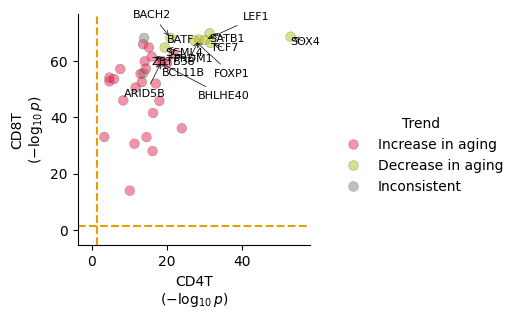

In [6]:
from ciim.src.tf_activity.plots import plot_joint_scatter

ttypes = ['CD8T', 'CD4T']
mask = interaction_main_df[ttypes].sum(axis=1)==len(ttypes)
features = mask[mask].index
# Get significant TFs for CD4T and CD8T cells
df = stats_sig[stats_sig['tf'].isin(features)].drop_duplicates(subset=['cell_type', 'tf'])
df['neg_log10_adj_pval'] = -np.log10(df['meta_p_adj'])

fig, ax = plt.subplots(1, 1, figsize=(3, 3))
plot_joint_scatter(df, vars=['CD4T', 'CD8T'], annotate=True, ax=ax)
ax.margins(x=0.1, y=0.1)

## GSEA

In [7]:
from ciim.src.tf_activity.helper import pathway_analysis_wrapper
type = 'bulk'
feature_type = 'tf_activity'
races = ['european', 'both']

pathway_scores_store = []
for race in races:
    stats_sig = retrieve_sig_stats(type, race=race)
    
    pathway_scores = pathway_analysis_wrapper(stats_sig)
    pathway_scores['race'] = race
    pathway_scores["neg_log10_adj_pval"] = -np.log10(pathway_scores["FDR"])
    pathway_scores_store.append(pathway_scores)
pathway_scores_all = pd.concat(pathway_scores_store)

(7, 10)
(3, 10)
(6, 10)
(2, 10)
(4, 10)
(9, 10)
(7, 10)
(1, 10)
(8, 10)
(6, 10)
(3, 10)
(7, 10)
(2, 10)
(8, 10)
(1, 10)
(2, 10)


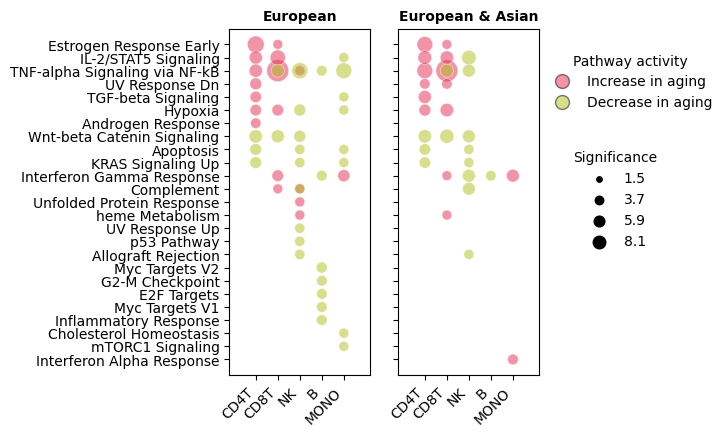

In [8]:
from ciim.src.tf_activity.plots import dotplot_category_color
from ciim.src.common import surrogate_names
    
fig, axes = plt.subplots(1, len(races), figsize=(2*len(races), 4.5), sharey=True, sharex=True)
for i, race in enumerate(races):
    ax = axes[i] if len(races)>1 else axes
    pathway_scores = pathway_scores_all[pathway_scores_all['race']==race]
    pathway_scores['cell_type'] = pd.Categorical(pathway_scores['cell_type'], categories=cell_types, ordered=True)
    if i == len(races)-1:
        show_color_legend = True
        show_size_legend = True
    else:
        show_color_legend = False
        show_size_legend = False
    dotplot_category_color(pathway_scores, 
                ax, 
                color_col='trend', 
                size_col='neg_log10_adj_pval', 
                x='cell_type', 
                y='Term', 
                palette=palette_trend_2, sizes=(50, 250),
                show_color_legend=show_color_legend, 
                show_size_legend=show_size_legend,
                size_legend_title='Significance',
                color_legend_title='Pathway activity',
                size_legend_loc=(1.2, 0.35),
                color_legend_loc=(1.02, 0.75),
                y_label='',
                alpha=0.5)
    ax.set_title(surrogate_names[race], fontsize=10, fontweight='bold')

In [9]:
pathway_scores['Term'].unique()

array(['TNF-alpha Signaling via NF-kB', 'Estrogen Response Early',
       'IL-2/STAT5 Signaling', 'TGF-beta Signaling', 'Hypoxia',
       'UV Response Dn', 'Wnt-beta Catenin Signaling', 'Apoptosis',
       'KRAS Signaling Up', 'Interferon Gamma Response',
       'heme Metabolism', 'Complement', 'Allograft Rejection',
       'Interferon Alpha Response'], dtype=object)

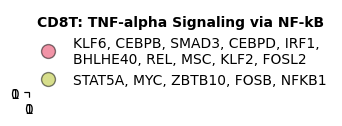

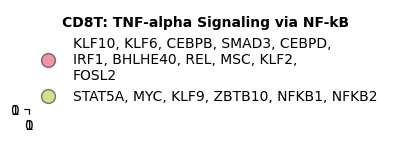

In [10]:
# - the term with bifurcation enrichment
term = 'TNF-alpha Signaling via NF-kB'
cell_type = 'CD8T'

from ciim.src.tf_activity.plots import plot_term_genes
for race in races:
    pathway_scores = pathway_scores_all[pathway_scores_all['race']==race]
    plot_term_genes(pathway_scores, cell_type, term)


In [11]:
from ciim.src.utils.util import get_genesets
pathways = get_genesets()
for key in pathways.keys():
    if 'STAT5' in key:
        print(key)
len(pathways['HALLMARK_IL2_STAT5_SIGNALING'])

HALLMARK_IL2_STAT5_SIGNALING


199

In [12]:
features = pathway_scores_all[(pathway_scores_all['Term']==term) & (pathway_scores_all['cell_type']==cell_type)].groupby('trend')['Genes'].apply(lambda x: x.str.split(';')).explode().unique()


True


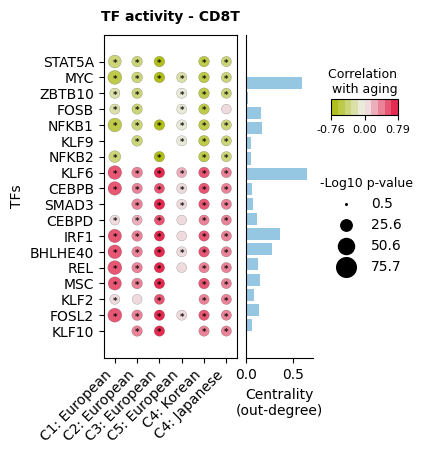

In [13]:
from ciim.src.tf_activity.plots import plot_features_vs_datasets
plot_features_vs_datasets(cell_type=cell_type, type=type, datasets=datasets_all, features=features, width=3.5,
                                feature_type='tf_activity', sizes=(50, 100), min_degree=1, filter_meta_significant=False)


# Minor cell types

## Heatmap

In [61]:
from ciim.src.common import mapping_minor_2_major
# - get the stats for bulk of both gender
race='both'
stats_store = []
for type in ['bulk', 'bulk_minor']:
    stats_tf = retrieve_stats_features(type, feature_type='tf_activity', condition='healthy', race=race)

    stats_tf = filter_for_consistent_trends(stats_tf) 
    # - add sig flags
    stats_sig = retrieve_sig_stats(type, race=race, filter_inconsistent=True).drop_duplicates(subset=['cell_type', 'tf']).set_index(['cell_type', 'tf'])
    stats_tf['is_significant'] = False
    stats_tf['is_significant'] = stats_tf.set_index(['cell_type', 'tf']).index.isin(stats_sig.index)

    stats_tf['major_cell_type'] = stats_tf['cell_type'].apply(lambda x: mapping_minor_2_major.get(x, x))
    stats_store.append(stats_tf)
stats_all_combined = pd.concat(stats_store, axis=0)[['major_cell_type', 'cell_type', 'tf', 'slope', 'is_significant']].drop_duplicates(subset=['cell_type', 'tf'])

# - plot
stats_all_combined['major_cell_type'] = stats_all_combined['major_cell_type'].astype(CategoricalDtype(categories=['CD4T', 'CD8T', 'NK', 'MONO', 'B'], ordered=True))


In [62]:
ordered_cell_names = ['CD4T',
                    'Tcm_Naive_CD4',
                    'Tem_Effector_CD4',
                    
                    'CD8T',
                    'Tem_Trm_CD8',
                    'Tem_Temra_CD8',
                    'Tcm_Naive_CD8',
                    'MAIT',

                    'NK',
                    'CD16_NK',
                    'MONO',
                    'Classic_MONO',
                    'NonClassic_MONO',
                    'B',
                    'Memory_B',
                    'Naive_B',
                    ]
stats_all_combined['cell_type'] = pd.Categorical(stats_all_combined['cell_type'], categories=ordered_cell_names, ordered=True)

In [63]:
stats_all_combined[(stats_all_combined['cell_type']=='MONO') & (stats_all_combined['is_significant'])]['tf'].nunique()
# retrieve_sig_stats(type='bulk_minor', race=race, cell_type='MONO').drop_duplicates(subset=['cell_type', 'tf'])['tf'].nunique()

50

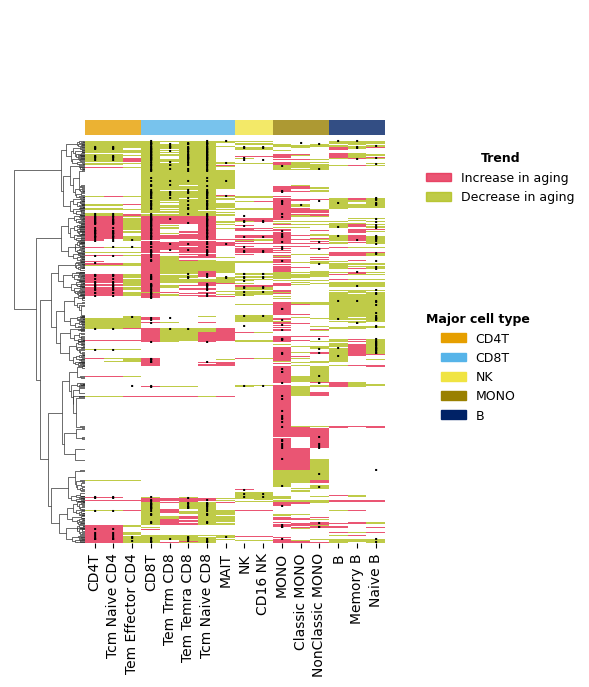

In [64]:
from ciim.src.tf_activity.plots import heamap_plot_minor_cell_types
heamap_plot_minor_cell_types(stats_all_combined, palette=palette_cell_types, figsize=(5, 7), sig_dots_y_offset=3, map_names={'cell_type':'Sub type', 'major_cell_type':'Major cell type'})

## Pathways

In [65]:
type = 'bulk_minor'
race = 'both'
stats_sig = retrieve_sig_stats(type=type, race=race)

pathway_scores = pathway_analysis_wrapper(stats_sig)

(1, 10)
(1, 10)
(3, 10)
(6, 10)
(1, 10)
(3, 10)
(2, 10)
(3, 10)
(2, 10)
(4, 10)
(7, 10)
(1, 10)
(6, 10)
(4, 10)
(3, 10)
(5, 10)


In [66]:
ordered_minors = ['Tcm_Naive_CD4',
                    'Tem_Effector_CD4',
                    
                    'Tem_Trm_CD8',
                    'Tem_Temra_CD8',
                    'Tcm_Naive_CD8',
                    'MAIT',
                    'NK',
                    'CD16_NK',
                    'MONO',
                    'Classic_MONO',
                    'NonClassic_MONO',
                    'Memory_B',
                    'Naive_B',]
ordered_minors = [item.replace('_', ' ') for item in ordered_minors]
pathway_scores['cell_type_pretty'] = pathway_scores['cell_type'].str.replace('_', ' ')
pathway_scores['cell_type_pretty'] = pd.Categorical(pathway_scores['cell_type_pretty'], categories=ordered_minors, ordered=True)
pathway_scores = pathway_scores[~pathway_scores['cell_type_pretty'].isna()]


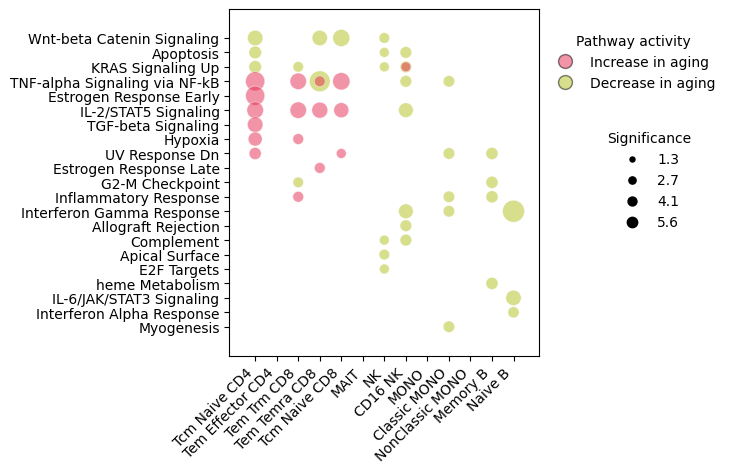

In [67]:
pathway_scores['neg_log10_adj_pval'] = -np.log10(pathway_scores["FDR"])
fig, ax = plt.subplots(1, 1, figsize=(4, 4.5))    

dotplot_category_color(pathway_scores, 
            ax, 
            color_col='trend', 
            size_col='neg_log10_adj_pval', 
            x='cell_type_pretty', 
            y='Term', 
            palette=palette_trend_2, sizes=(50, 250),
            show_color_legend=show_color_legend, 
            show_size_legend=show_size_legend,
            size_legend_title='Significance',
            color_legend_title='Pathway activity',
            size_legend_loc=(1.2, 0.35),
            color_legend_loc=(1.02, 0.75),
            y_label='',
            alpha=0.5)
ax.margins(x=.1, y=.1)
# ax.set_title(surrogate_names[race], fontsize=10, fontweight='bold')

In [70]:
pathway_scores['Term'].unique()

array(['Wnt-beta Catenin Signaling', 'Apoptosis', 'KRAS Signaling Up',
       'TNF-alpha Signaling via NF-kB', 'Estrogen Response Early',
       'IL-2/STAT5 Signaling', 'TGF-beta Signaling', 'Hypoxia',
       'UV Response Dn', 'Estrogen Response Late', 'G2-M Checkpoint',
       'Inflammatory Response', 'Interferon Gamma Response',
       'Allograft Rejection', 'Complement', 'Apical Surface',
       'E2F Targets', 'heme Metabolism', 'IL-6/JAK/STAT3 Signaling',
       'Interferon Alpha Response', 'Myogenesis'], dtype=object)

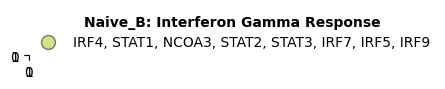

In [71]:
from ciim.src.tf_activity.plots import plot_term_genes
term= 'Interferon Gamma Response' #'TNF-alpha Signaling via NF-kB' 
plot_term_genes(pathway_scores, cell_type='Naive_B', term=term)
# plot_term_genes(pathway_scores, cell_type='Tcm_Naive_CD8', term=term)

No data for Tcm_Naive_CD8 source


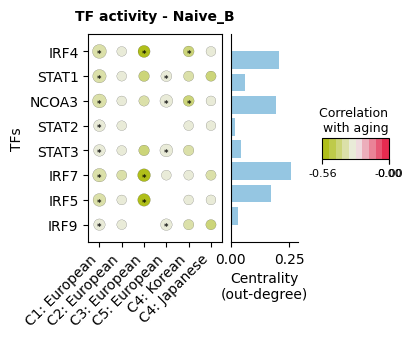

In [72]:
from ciim.src.tf_activity.plots import plot_features_vs_datasets
for cell_type in ['Naive_B', 'Tcm_Naive_CD8']:
    features = pathway_scores[(pathway_scores['Term']==term) & (pathway_scores['cell_type']==cell_type)].groupby('trend')['Genes'].apply(lambda x: x.str.split(';')).explode().unique()

    plot_features_vs_datasets(cell_type=cell_type, type=type, datasets=datasets_all, features=features, width=3.5,
                                    feature_type='tf_activity', sizes=(50, 100), min_degree=1, filter_meta_significant=False)


## Interaction of subtypes

['Tcm_Naive_CD8', 'Tem_Temra_CD8', 'Tem_Trm_CD8']


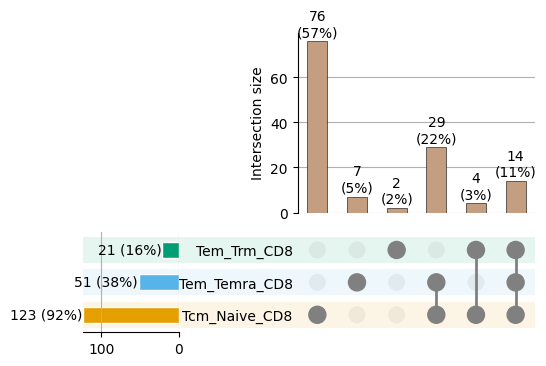

In [73]:
from task_grn_inference.src.exp_analysis.helper import plot_interactions, create_interaction_df
type = 'bulk_minor'
race = 'both'

minor_types = ['Tem_Trm_CD8',
                'Tem_Temra_CD8',
                'Tcm_Naive_CD8',]

stats_sig = retrieve_sig_stats(type, race=race).drop_duplicates(subset=['cell_type', 'tf'])
stats_sig = stats_sig[stats_sig['cell_type'].isin(minor_types)]
df_dict = stats_sig.groupby(['cell_type'])['tf'].apply(list).to_dict()
interaction_main_df = create_interaction_df(df_dict)
aa = plot_interactions(interaction_main_df, min_subset_size=2, color_map=None)

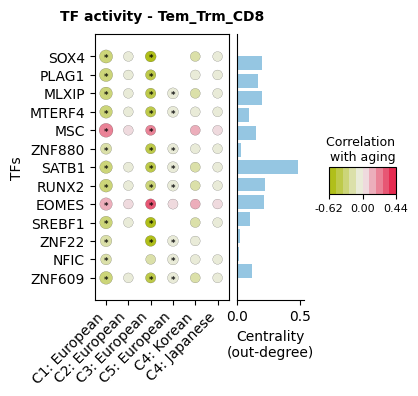

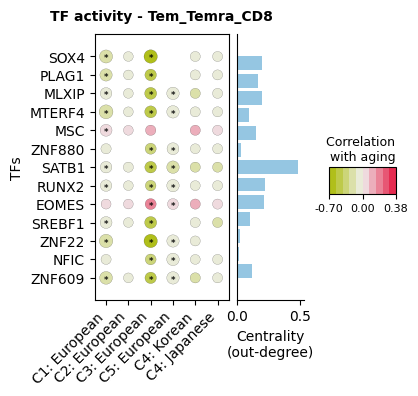

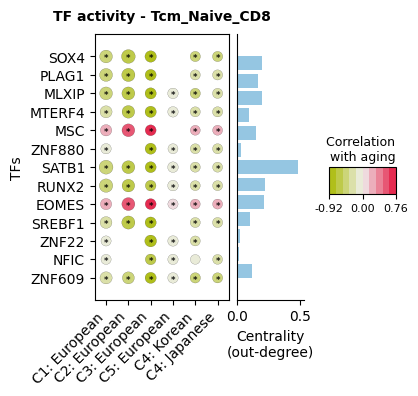

In [74]:
# - shared features
from ciim.src.tf_activity.plots import plot_features_vs_datasets
# - plot the common ones
features = interaction_main_df[interaction_main_df.sum(axis=1)==3].index
for cell_type in minor_types:
    plot_features_vs_datasets(cell_type=cell_type, type=type, datasets=datasets_all, features=features, width=3.5,
                                feature_type='tf_activity', sizes=(50, 100), min_degree=1, filter_meta_significant=True)


In [80]:
stats_sig['cell_type'].unique()

array(['Tcm_Naive_CD8', 'Tem_Temra_CD8', 'Tem_Trm_CD8'], dtype=object)

(18,)


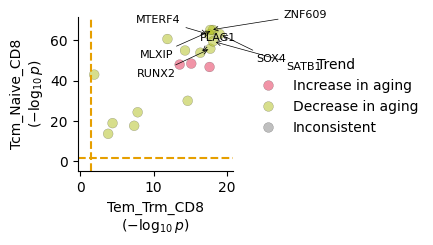

In [75]:
from ciim.src.tf_activity.plots import plot_joint_scatter

vars = ['Tem_Trm_CD8',
                'Tcm_Naive_CD8']
interaction_main_ts_df = interaction_main_df[vars]
sig_tfs_ts = interaction_main_ts_df[interaction_main_ts_df.sum(axis=1)==2].index
print(sig_tfs_ts.shape)
# Get significant TFs for CD4T and CD8T cells
df = stats_sig[stats_sig['tf'].isin(sig_tfs_ts)].drop_duplicates(subset=['cell_type', 'tf'])
df['neg_log10_adj_pval'] = -np.log10(df['meta_p_adj'])

fig, ax = plt.subplots(1, 1, figsize=(2, 2))
plot_joint_scatter(df, vars=vars, annotate=True, ax=ax)
ax.margins(x=0.1, y=0.1)

Index(['ZBTB16', 'RELB', 'PBX4', 'ZBTB10', 'NFKB2', 'CEBPD', 'ZNF331'], dtype='object')


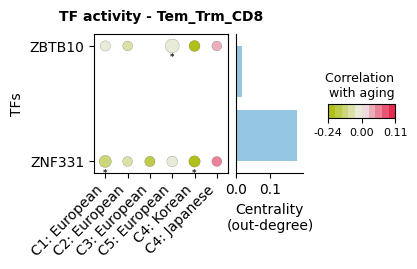

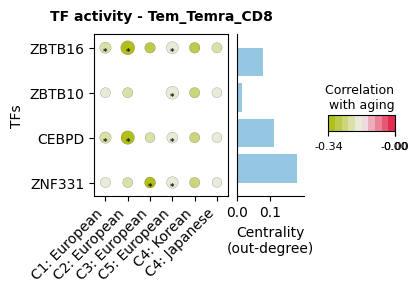

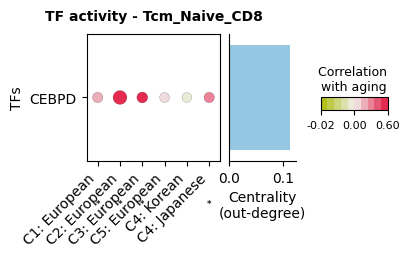

In [76]:
# - unique to one cell type
cell_type = 'Tem_Temra_CD8'
unique_interactions = interaction_main_df[interaction_main_df.sum(axis=1)==1]
features = unique_interactions[unique_interactions[cell_type]].index
print(features)
for cell_type in minor_types:
    plot_features_vs_datasets(cell_type=cell_type, type=type, datasets=datasets_all, features=features, width=3.5,
                                feature_type='tf_activity', sizes=(50, 100), min_degree=1, filter_meta_significant=True)

True


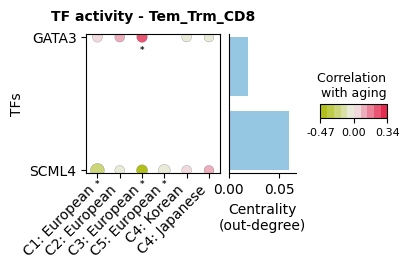

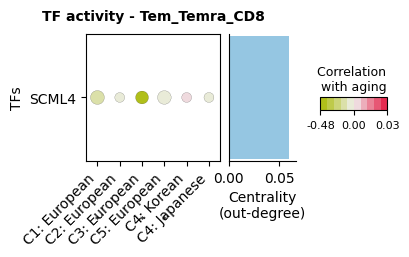

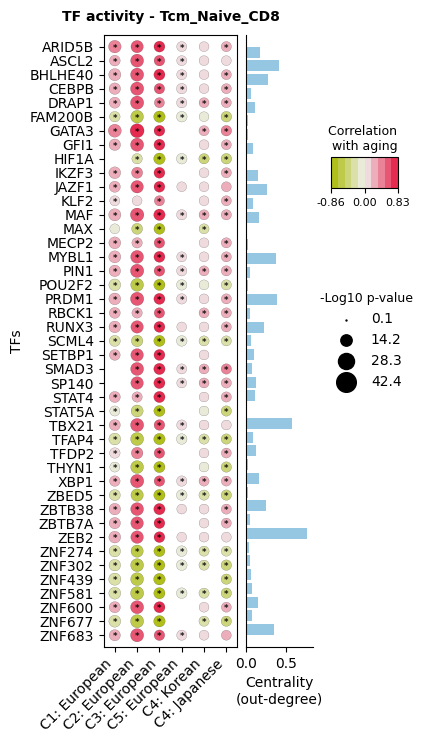

In [77]:
# - unique to one minor cell type
cell_type = 'Tcm_Naive_CD8'
unique_interactions = interaction_main_df[interaction_main_df.sum(axis=1)==1]
features = unique_interactions[unique_interactions[cell_type]].index
features = np.sort(features)
for cell_type in minor_types:
    plot_features_vs_datasets(cell_type=cell_type, type=type, datasets=datasets_all, features=features, width=3.5,
                                feature_type='tf_activity', sizes=(50, 100), min_degree=1, filter_meta_significant=True, margins={'x': 0.1, 'y': 0.02})

# STD

In [27]:
# - get the stats for bulk of bulk and sc
stats_store = []
for type in ['bulk', 'sc_std']:
    stats_tf = pd.read_csv(f'../output/tf_activity/stats_tfs_{type}.csv')
    stats_tf = stats_tf[(stats_tf['condition']=='healthy')] 
    stats_tf = filter_for_consistent_trends(stats_tf) # change this to include inconsistent ones
    # - add valid cases
    stats_valid = retrieve_sig_stats(type, analysis='european').drop_duplicates(subset=['cell_type', 'tf'])
    stats_tf['is_significant'] = False
    stats_tf['is_significant'] = (stats_tf['tf'].isin(stats_valid['tf'])) & (stats_tf['cell_type'].isin(stats_valid['cell_type']))
    
    stats_tf['type'] = type
    stats_store.append(stats_tf)
stats_all_combined = pd.concat(stats_store, axis=0)[['cell_type', 'tf', 'slope', 'type', 'is_significant']].drop_duplicates(subset=['cell_type', 'tf', 'type', 'is_significant'])

# - plot
stats_all_combined['type'] = stats_all_combined['type'].map({'bulk': 'Bulk', 'sc': 'STD'}).astype(CategoricalDtype(categories=['Bulk', 'STD'], ordered=True))
stats_all_combined['cell_type'] = stats_all_combined['cell_type'].astype(CategoricalDtype(categories=['CD4T', 'CD8T', 'NK', 'MONO', 'B'], ordered=True))

from ciim.src.tf_activity.plots import plot_overall_heatmap

plot_overall_heatmap(stats_all_combined, 
                    sig_dots_y_offset=5, 
                    first_col='cell_type',  first_col_palette=palette_cell_types,
                    second_col='type', second_col_palette={'Bulk': 'gray', 'STD': 'lightblue'},
                    figsize=(4, 7),
                    map_names={'cell_type':'Cell type', 'type': 'Analysis'})

FileNotFoundError: [Errno 2] No such file or directory: '../output/tf_activity/stats_tfs_bulk.csv'

In [73]:
cell_type = 'CD8T'

stats_valid_store = []
for type in ['bulk', 'sc']:
    stats_valid = retrieve_valid_stats(type)
    stats_valid = stats_valid[stats_valid['cell_type'].isin([cell_type])]

    nets = pd.read_csv(f'../output/tf_activity/sig_nets_{type}.csv')
    nets = nets[nets['cell_type'].isin([cell_type])]
    central_tfs = nets.groupby(['source']).size().sort_values(ascending=False).head(40).index.to_numpy()
    stats_valid = stats_valid[stats_valid['tf'].isin(central_tfs)]
    # stats_valid = stats_valid.sort_values('meta_p_adj', ascending=True).head(30)
    stats_valid['type'] = type
    stats_valid['cell_type'] = cell_type
    stats_valid_store.append(stats_valid)
stats_valid_all = pd.concat(stats_valid_store, axis=0)
stats_valid_all['neg_log10_adj_pval'] = -np.log10(stats_valid_all['meta_p_adj'])
stats_valid_all['type'] = stats_valid_all['type'].map({'bulk': 'Bulk', 'sc': 'STD'}).astype(CategoricalDtype(categories=['Bulk', 'STD'], ordered=True))


# Gender


## Overall plot

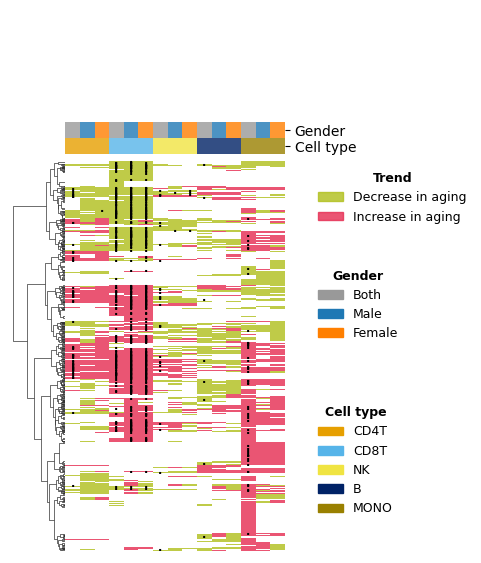

In [46]:
# - get the stats for bulk of both gender
from ciim.src.tf_activity.helper import retrieve_stats_features
stats_store = []
race='both'

for type in ['bulk', 'bulk_M', 'bulk_F']:
    stats_tf = retrieve_stats_features(type, feature_type='tf_activity', condition='healthy', race=race)
    stats_tf = filter_for_consistent_trends(stats_tf) 
    # - add valid cases
    stats_sig = retrieve_sig_stats(type, race=race).drop_duplicates(subset=['cell_type', 'tf']).set_index(['cell_type', 'tf'])
    stats_tf['is_significant'] = False
    stats_tf['is_significant'] = stats_tf.set_index(['cell_type', 'tf']).index.isin(stats_sig.index)
    
    # stats_tf['is_significant'] = (stats_tf['tf'].isin(stats_sig['tf'])) & (stats_tf['cell_type'].isin(stats_sig['cell_type']))
    
    stats_tf['gender'] = type
    stats_store.append(stats_tf)
stats_all_combined = pd.concat(stats_store, axis=0)[['cell_type', 'tf', 'slope', 'gender', 'is_significant']].drop_duplicates(subset=['cell_type', 'tf', 'gender', 'is_significant'])

# - plot
stats_all_combined['gender'] = stats_all_combined['gender'].map({'bulk': 'Both', 'bulk_F': 'Female', 'bulk_M': 'Male'}).astype(CategoricalDtype(categories=['Both', 'Male', 'Female'], ordered=True))
stats_all_combined['cell_type'] = stats_all_combined['cell_type'].astype(CategoricalDtype(categories=cell_types, ordered=True))

from ciim.src.tf_activity.plots import plot_overall_heatmap

plot_overall_heatmap(stats_all_combined, 
                    sig_dots_y_offset=3, 
                    first_col='cell_type',  first_col_palette=palette_cell_types,
                    second_col='gender', second_col_palette={**{'Both': 'gray', **palette_genders}},
                    figsize=(4, 7),
                    map_names={'cell_type':'Cell type', 'gender': 'Gender'})

In [47]:
# stats_all_combined[stats_all_combined['cell_type']=='MONO']['tf'].nunique()

527

## Interactions

In [2]:
race = 'both'
stats_sig_M  = retrieve_sig_stats(type='bulk_M', race=race).drop_duplicates(subset=['cell_type', 'tf'])
stats_sig_M['gender'] = 'Male'
stats_sig_F = retrieve_sig_stats(type='bulk_F', race=race).drop_duplicates(subset=['cell_type', 'tf'])
stats_sig_F['gender'] = 'Female'
stats_sig_all = pd.concat([stats_sig_M, stats_sig_F])


if True:
    # - find tfs with opposite trends
    features_dict = {}
    for cell_type in cell_types:
        stats_t = stats_sig_all[stats_sig_all['cell_type'] == cell_type]
        mask = stats_t.groupby('tf')['slope'].apply(lambda x: np.sign(x).nunique() == 2)
        tfs = mask[mask].index.tolist()
        features_dict[cell_type] = tfs

    print('tfs with opposite trends: ', features_dict)

# - find tfs sig in one gender and not the other
features_dict = {}
for cell_type in ['CD8T']:
    stats_t = stats_sig_all[stats_sig_all['cell_type'] == cell_type]  
    sig_tfs_M = stats_t[stats_t['gender']=='Male']['tf'].unique()
    sig_tfs_F = stats_t[stats_t['gender']=='Female']['tf'].unique()
    features_dict[cell_type] = np.setxor1d(sig_tfs_M, sig_tfs_F)
    print(features_dict[cell_type])
    aa

print('tfs sig in one and not the other: ', features_dict)

tfs with opposite trends:  {'CD4T': [], 'CD8T': [], 'NK': [], 'B': [], 'MONO': []}
['AHR' 'CREM' 'FLI1' 'HMGN3' 'JUNB' 'KLF2' 'MAFF' 'MXI1' 'NFIC' 'NR1H2'
 'RELB' 'SNAI1' 'ZNF267' 'ZNF331' 'ZNF740']


NameError: name 'aa' is not defined

In [4]:
stats_all = pd.read_csv(f'../output/tf_activity/stats_all_bulk_M.csv')
mask = (stats_all['condition']=='healthy') & (stats_all['cell_type']=='CD8T') & (stats_all['tf']=='AHR')
stats_all[mask]

,tf,p_value,slope,p_value_adj,condition,dataset,cell_type,meta_p,meta_p_adj,neg_log10_adj_pval,trend,race
851,AHR,0.005517,-0.340477,0.006943,healthy,data13_Japanese,CD8T,0.005517,0.007411,2.130114,Decrease in aging,both
1182,AHR,0.003669,-0.358090,0.004644,healthy,data13_Korean,CD8T,0.005517,0.007411,2.130114,Decrease in aging,both


Only 4 datasets are available in the stats.
True
Only 4 datasets are available in the stats.
True


Text(0.5, 1.1, 'Male')

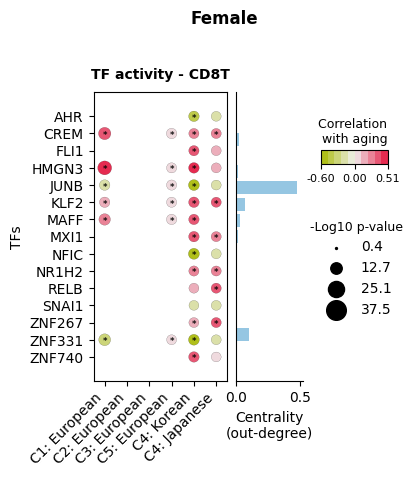

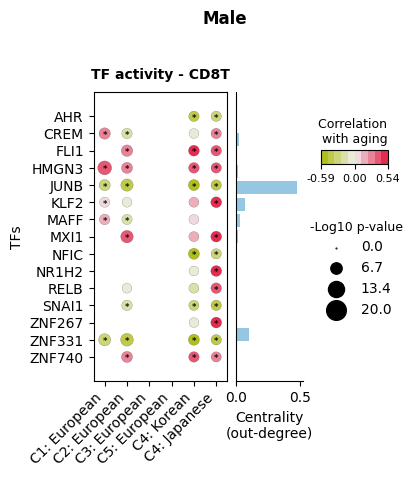

In [3]:
from ciim.src.tf_activity.plots import plot_features_vs_datasets
cell_type='CD8T'

features = features_dict[cell_type]
# features = ['FOSB', 'JUND', 'JUNB', 'ELF4', 'NR4A2']

# plot_features_vs_datasets(cell_type=cell_type, type='bulk', datasets=datasets_all, features=features
#                         , width=3.5, feature_type='tf_activity', sizes=(50, 100), min_degree=1, filter_meta_significant=False)
# plt.suptitle('Both', fontsize=12, y=1.1, fontweight='bold')
plot_features_vs_datasets(cell_type=cell_type, type='bulk_F', datasets=datasets_all, features=features
                        , width=3.5, feature_type='tf_activity', sizes=(50, 100), min_degree=1, filter_meta_significant=False)
plt.suptitle('Female', fontsize=12, y=1.1, fontweight='bold')
plot_features_vs_datasets(cell_type=cell_type, type='bulk_M', datasets=datasets_all, features=features
                        , width=3.5, feature_type='tf_activity', sizes=(50, 100), min_degree=1, filter_meta_significant=False)
plt.suptitle('Male', fontsize=12, y=1.1, fontweight='bold')

In [ ]:
# from ciim.src.tf_activity.helper import pathway_analysis_wrapper
# type = 'bulk_M'
# race = 'european'
# stats_sig = retrieve_sig_stats(type, race=race)

# features = features_dict[cell_type]
# races = ['european', 'asian']

# pathway_scores_store = []
# for race in races:
    
#     pathway_scores = pathway_analysis_wrapper(stats_sig)
#     pathway_scores["neg_log10_adj_pval"] = -np.log10(pathway_scores["Adjusted P-value"])
#     pathway_scores['race'] = race
#     pathway_scores_store.append(pathway_scores)
# pathway_scores_all = pd.concat(pathway_scores_store)

In [ ]:
# plot_feature_values_all_datasets(cell_type, feature=case_tf, feature_type=feature_type, type=type, datasets=datasets_all, show_cbar=True)


# Trajectory plot: TF acitvity with age


(981, 76)
(313, 185)
(61, 172)
(150, 79)
(981,) (981,) (981,)
(313,) (313,) (313,)
(61,) (61,) (61,)
(150,) (150,) (150,)


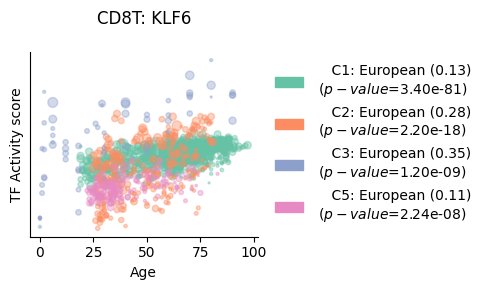

In [20]:

from ciim.src.tf_activity.plots import plot_trends
from ciim.src.common import palette_datasets, datasets_e
if True:
    datasets = datasets_e
    # # - load data
    if True:
        cell_type = 'CD8T'
        adata_complete = {dataset: retrieve_adata_bulk(dataset) for dataset in datasets}
        adata_dict = {dataset: adata[adata.obs['cell_type'] == cell_type] for dataset, adata in adata_complete.items()}
        nets_dict = {dataset: retrieve_net(dataset, cell_type) for dataset in datasets}
        tf_acts_dict = {}
        for dataset in datasets:
            tf_acts = calculate_tf_activity(adata_dict[dataset], nets_dict[dataset])
            print(tf_acts.shape)
            tf_acts_dict[surrogate_names[dataset]] = tf_acts

    cell_type = 'CD8T'
    genes = ['KLF6']
    
    plot_trends(top_tfs=genes, datasets=[surrogate_names[d] for d in datasets], data_dict=tf_acts_dict, palette=palette_datasets_pretty, cell_type=cell_type, surrogate_names=surrogate_names)
    plt.yticks([])
    plt.tight_layout()
    plt.savefig(f'../output/tf_activity/trends_{cell_type}_case.png', dpi=300)

In [41]:
data_df['cohort'].unique()

['C3: European', 'C5: European', 'C2: European', 'C1: European']
Categories (4, object): ['C3: European' < 'C5: European' < 'C2: European' < 'C1: European']

Spearman correlations per cohort:

Meta-analysis combined p-value (Fisher's method): 6.258559317395964e-94


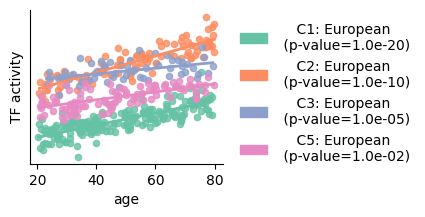

In [51]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, combine_pvalues
import matplotlib.pyplot as plt

# Step 1: Generate random data
np.random.seed(42)  # for reproducibility

n_samples_list = [200, 100, 60, 100]  # number of samples per cohort
cohorts = datasets_e

data = []

# Define base slope and intercept
base_slope = 0.05
base_intercept = 0.5

for i,cohort in enumerate(cohorts):
    n_samples = n_samples_list[i]
    ages = np.random.uniform(20, 80, size=n_samples)
    
    # Slight random shifts in slope and intercept for each cohort
    slope_shift = np.random.normal(0, 0.02)
    intercept_shift = np.random.normal(0, 4)
    
    tf_activity = (base_slope + slope_shift) * ages + (base_intercept + intercept_shift)
    tf_activity += np.random.normal(0, 0.5, size=n_samples)  # add noise
    
    cohort_df = pd.DataFrame({
        'cohort': cohort,
        'age': ages,
        'tf_activity': tf_activity
    })
    
    data.append(cohort_df)

# Combine into one dataframe
data_df = pd.concat(data, ignore_index=True)
data_df['cohort'] = data_df['cohort'].astype(pd.CategoricalDtype(categories=cohorts, ordered=True))
# Step 2: Calculate Spearman correlation per cohort
results = []
for cohort in cohorts:
    subset = data_df[data_df['cohort'] == cohort]
    corr, pval = spearmanr(subset['age'], subset['tf_activity'])
    results.append({'cohort': cohort, 'spearman_corr': corr, 'pval': pval})

results_df = pd.DataFrame(results)
print("Spearman correlations per cohort:")
_, combined_pval = combine_pvalues(results_df['pval'])

print("\nMeta-analysis combined p-value (Fisher's method):", combined_pval)

# (Optional) Step 4: Plotting
import seaborn as sns
fig, ax = plt.subplots(figsize=(2.5, 2))
for cohort in data_df['cohort'].unique():
    subset = data_df[data_df['cohort'] == cohort]
    sns.regplot(data=subset, x='age', y='tf_activity', ax=ax, 
                scatter_kws={'s': 20}, line_kws={'linewidth':2},
                color=palette_datasets[cohort], label=cohort, ci=None)

# ax.legend(title='Cohort', loc=(1.1, .2), frameon=False)
p_values = [1E-20, 1E-10, 1E-5, 1E-2]
legend_handles = []
for i, d in enumerate(cohorts):
    p_value = p_values[i]
    legend_label = '    ' + surrogate_names[d] +'\n' + r' (p-value=' + "{:.1e}".format(p_value) + ")"

    handle = mpatches.Patch(color=palette_datasets[d], label=legend_label)
    legend_handles.append(handle)
ax.legend(handles=legend_handles, loc='upper left', bbox_to_anchor=(1.02, 1), frameon=False)
ax.spines[['top', 'right']].set_visible(False)
ax.set_yticks([])
ax.set_ylabel('TF activity')
plt.show()

## TF activity trend vs expression trend in aging


In [52]:
# --------------- add the stats obtained from expression data (rather than TF activity)
from ciim.src.tf_activity.helper import determine_stats, retrieve_adata_bulk

stats_store = []
for dataset in datasets:
    adata = retrieve_adata_bulk(dataset)
    for cell_type in cell_types:
        print(f'dataset: {dataset}, cell_type: {cell_type}')
        stats_all_sig_df = stats_all_sig[stats_all_sig['cell_type'] == cell_type]
        adata_sub = adata[adata.obs['cell_type'] == cell_type]
        sig_tfs = stats_all_sig_df['tf'].unique()
    
        stats = determine_stats(adata_sub, sig_tfs)
        stats['dataset'] = dataset
        stats['cell_type'] = cell_type
        stats_store.append(stats)
expression_stats_all = pd.concat(stats_store).reset_index(drop=True)
expression_stats_all.head()
from src.tf_activity.plots import plot_activation_vs_expression
df = stats_all_sig_combined.copy()
df = df[df['cell_type']=='CD8T']
plot_activation_vs_expression(df, y_label='Activation significance', x_label='Expression significance')
plt.suptitle("TF activation vs expression (CD8T)", y=1.05, fontsize=14)
plt.tight_layout()
plt.savefig(f'../output/tf_activity/activation_vs_expression.png', dpi=300)

ImportError: cannot import name 'determine_stats' from 'ciim.src.tf_activity.helper' (/home/jnourisa/projs/ongoing/ciim/src/tf_activity/helper.py)